# Getting Started with Pyomo.DoE

Model-based design uses physics-based models. It starts with prior knowledge and iterates through the loop until a satisfactory model is found. We have already discussed parameter estimation in the first part of the workshop. If we have multiple models, we can discriminate among them to find the best model that fits the data. However, that is not a part of this workhsop. 

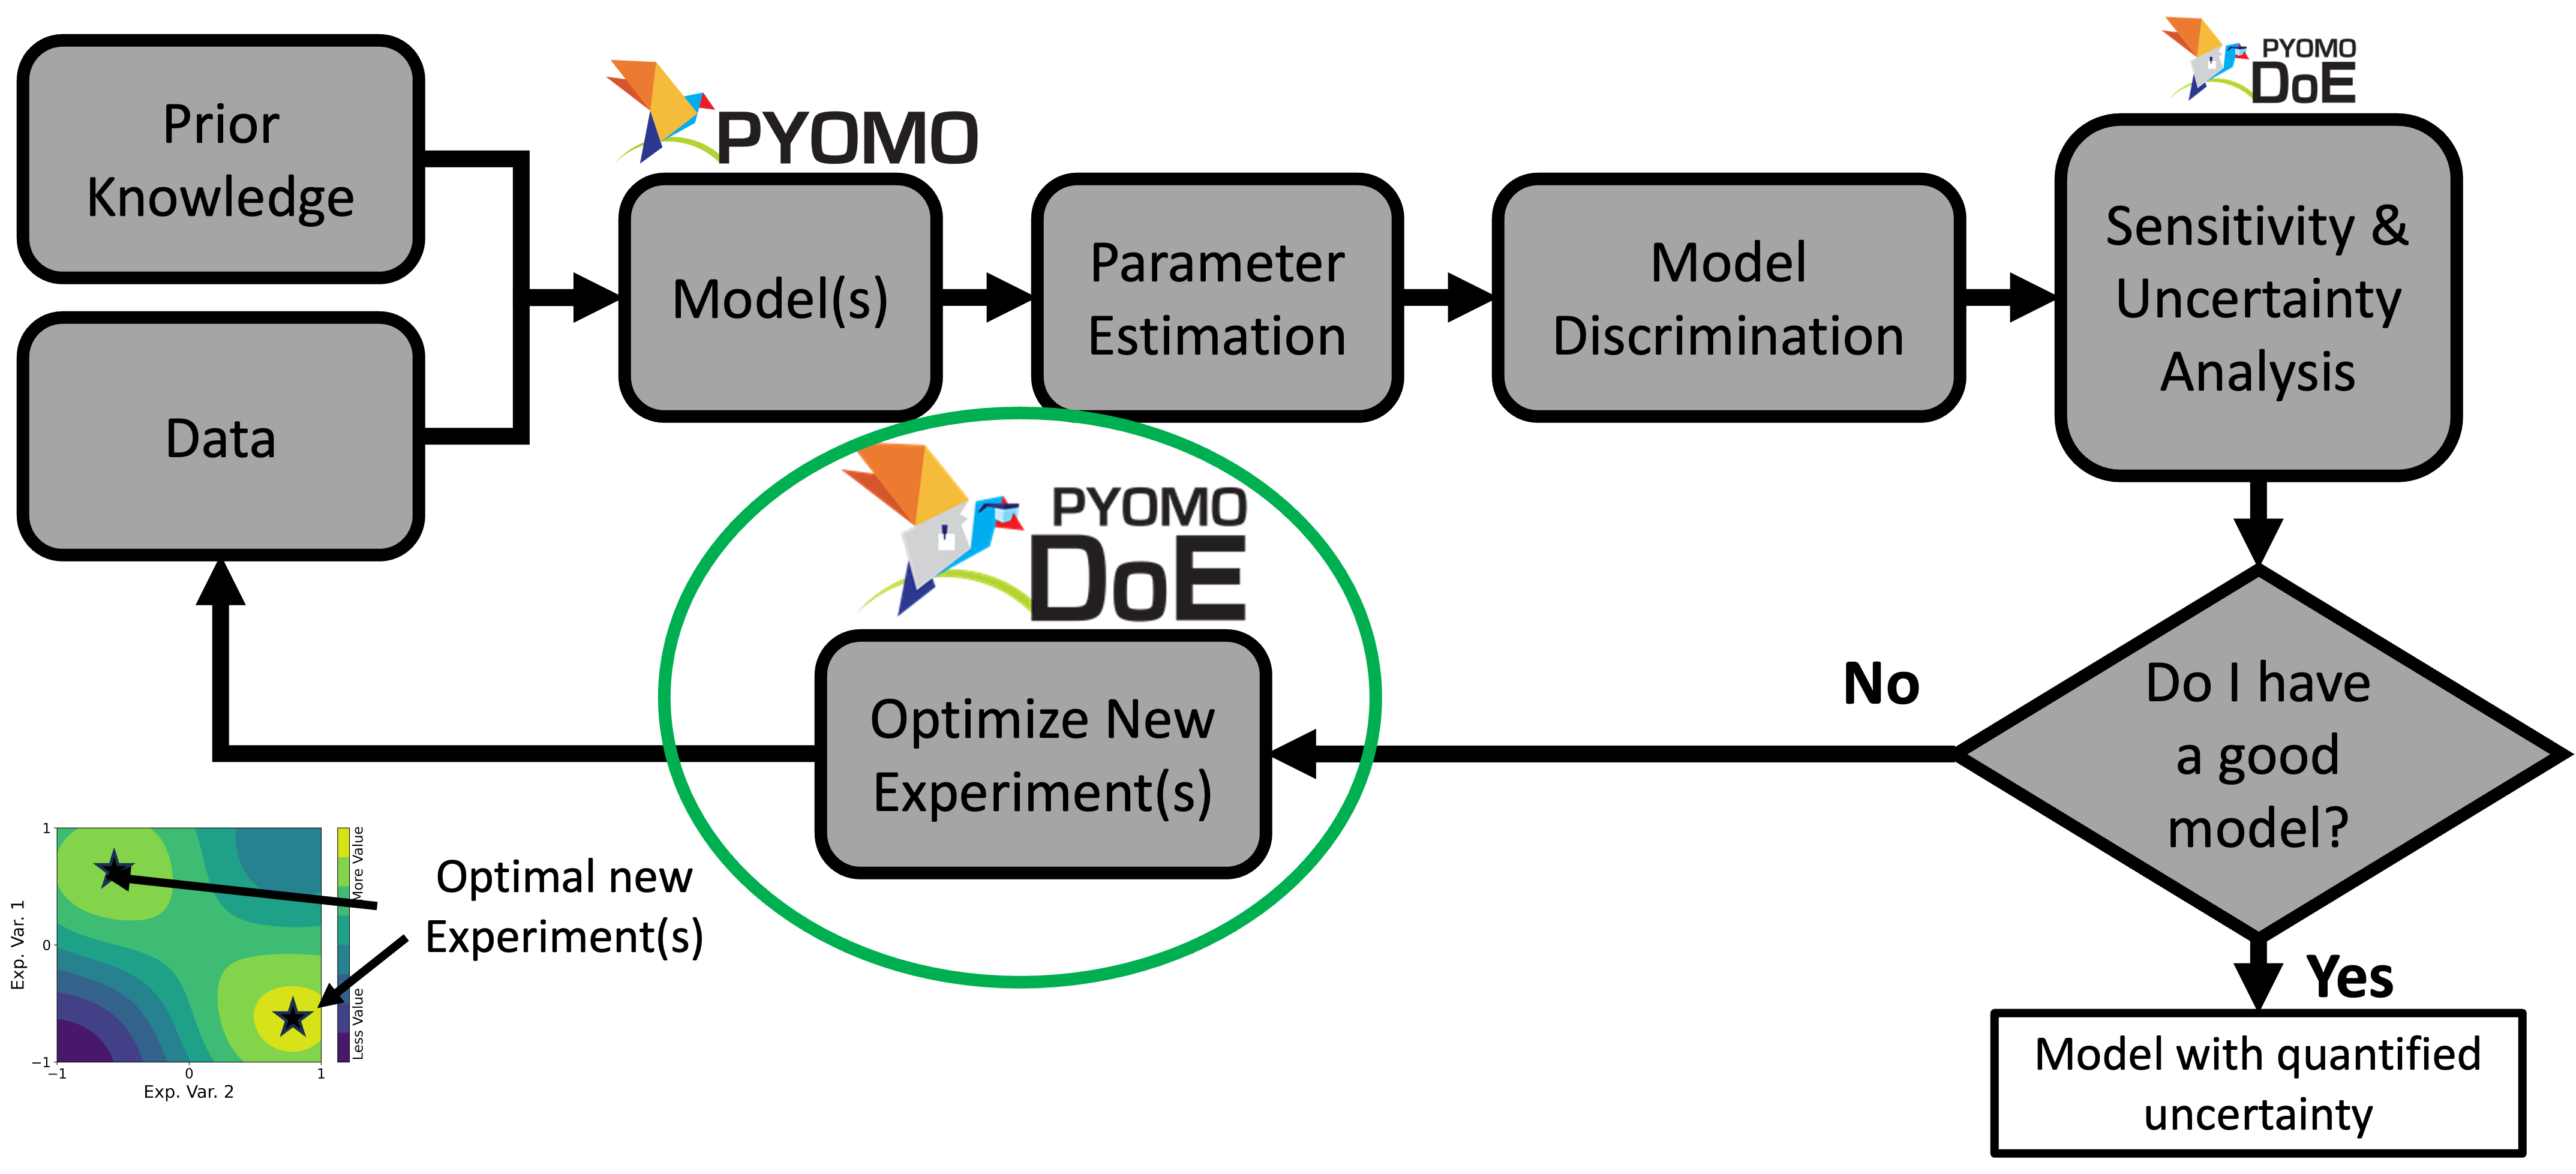

In the `optimize new experiments` step, we can design a single experiment (sequential design), or we can design multiple experiments (multi-experiment design). We will discuss both in this workshop.
## Fisher information matrix
The covariance matrix ($\mathbf{V}$) can be approximated as the inverse of the Fisher information matrix ($\mathbf{M}$). Mathematically,
$$
\mathbf{V}(\hat{\boldsymbol{\theta}}) \approx \mathbf{M}(\hat{\boldsymbol{\theta}})^{-1}
$$
For a normally distriuted measurement error, the Fisher information matrix (FIM) can be defined as 
$$
\mathbf{M}(\hat{\boldsymbol{\theta}}) = \left(\left. \frac{\partial \hat{\mathbf{y}}}{\partial \boldsymbol{\theta}}\right|_{\hat{\boldsymbol{\theta}}}\right)^{\top} \Sigma_{\mathbf{y}}^{-1} \left(\left. \frac{\partial \hat{\mathbf{y}}}{\partial \boldsymbol{\theta}}\right|_{\hat{\boldsymbol{\theta}}}\right)
$$
 Where, 
- $\hat{\mathbf{y}}$ is the vector of model responses
- $\mathbf{y}$ is the measured responses 
- $\Sigma_{\mathbf{y}}$ is the measurement error covariance matrix
- $\boldsymbol{\theta}$ is the vector of unknown parameters
- $\hat{\boldsymbol{\theta}}$ is the vector of nominal values of the parameters


## Optimization Formulation
Maximize a scalar-valued function $\psi(\cdot)$ of the Fisher information matrix $\mathbf{M}$:

$$
\begin{align*}
\max_{u} \quad & \psi(\mathbf{M}(u) + \mathbf{M}_0) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t)\\
& C_p^S \frac{dT_S}{dt} = U_b (T_H - T_S)  \\
& 0\% \leq u(t) \leq 100 \% \\
& T_H(t_0) = T_{amb} \\
& T_S(t_0) = T_{amb}
\end{align*}
$$

Here, $\mathbf{M}_0$ is the prior Fisher information matrix, i.e., Fisher information matrix from prior experiments and $u$ is the design variable. Design variables are the experimental conditions which can be controlled during the experiment. In our TC Lab example, design variable is the heater power. The overall goal is to optimize a scalar metric of the Fisher information matrix by changing the design variable.

`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem. Here, we will start with the simplest objective defined as $\psi(\cdot) = \log_{10}(\mathrm{trace(FIM)})$, i.e., pseudo-A-optimality. There are other many other optimality criteria. A-, D-, E, and ME-optimality will be presented later. In this section, we will see how to design an experiment using pseudo-A-optimality.

## Optimal design of experiments

In [1]:
# Import necessary packages and functions
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

### Load experimental data (sine test)

We load the sine-test experimental data to initialize the model. Our `create_model` function uses the supplied data to set initial values for the Pyomo variables. Careful initialization is often important when solving large-scale dynamic optimization problems.

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df[['Time', 'T1', 'Q1', 'Q2']].head() # the Q2 column entries are 0 because 
                                      # we are considering the two-state model (Q1, T1)

,Time,T1,Q1,Q2
0,0.00,22.2,50,0
1,1.01,22.2,51,0
2,2.01,22.2,52,0
3,3.00,22.2,53,0
4,4.01,22.2,54,0


For completeness, we will visualize the data again.

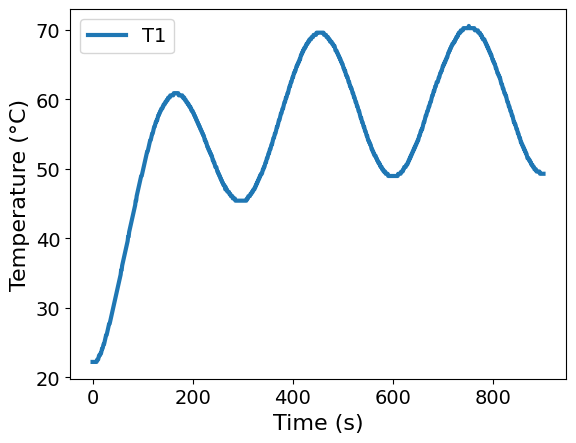

In [3]:
ax = df.plot(x='Time', y=['T1'], xlabel='Time (s)', ylabel='Temperature (°C)')

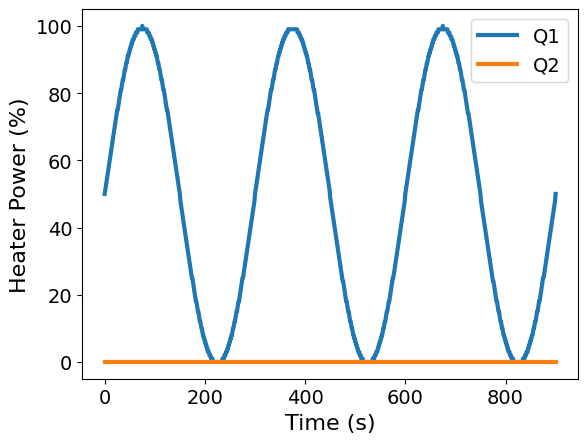

In [4]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

And then we will store the data in an instance of our `TC_Lab_data` dataclass to help us organize the data.

In [5]:
# Here, we will induce a step size of 6 seconds, as to not to make the problem too large,
# so that we can solve the problem in manageable time.
skip = 6

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

### Use prior parameter information

As shown earlier, the model is not estimable in its original form, so we used regularization in the previous notebook. Here, we reuse the resulting parameter estimates and covariance matrix as prior information for experimental design.

In [6]:
import numpy as np

# Theta values estimated from the regularized regresssion in the previous notebook
# L2 regularization
theta_values = {
    'Ua': 0.041705,
    'Ub': 0.012009,
    'inv_CpH': 0.167457,
    'inv_CpS': 4.545432,
}

# L2 regularization (diagonal)
cov = np.array([[1.857017e-10, -2.576198e-10, 1.402148e-09, -2.242347e-12],
               [-2.576198e-10, 1.624383e-07, 9.109870e-08, -6.325555e-05],
               [1.402148e-09, 9.109870e-08, 1.031454e-07, -3.890789e-05],
               [-2.242347e-12, -6.325555e-05, -3.890789e-05, 2.499914e-02]]
               )
PRIOR_FIM = np.linalg.inv(cov)

# Let's look at the FIM to see how informative our prior is before optimization
results_summary(PRIOR_FIM)

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.910298890895081
A-optimality: -1.6020703142934263
D-optimality: 27.781982236650098
E-optimality: 1.6020710987913134
Modified E-optimality: 8.254407420205586

FIM:
 [[ 7.17766325e+09  1.00811757e+08 -2.18902252e+08 -8.56071665e+04]
 [ 1.00811757e+08  8.99331580e+08  1.51888631e+08  2.51198161e+06]
 [-2.18902252e+08  1.51888631e+08  5.68992000e+07  4.72881315e+05]
 [-8.56071665e+04  2.51198161e+06  4.72881315e+05  7.13206905e+03]]

eigenvalues:
 [7.18585615e+09 9.25285788e+08 2.27591861e+07 4.00010230e+01]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.9994    0.0098    0.0326   -0.0000
Ub         0.0153   -0.9846   -0.1743   -0.0025
inv_CpH   -0.0304   -0.1747    0.9842   -0.0016
inv_CpS   -0.0000   -0.0028    0.0011    1.0000


From the eigendecomposition, we see that we have the least confidence in `inv_CpS` and the highest confidence in `Ua`. We now design the next experiment to improve parameter precision.

### Optimize next experiment (Pseudo-A-optimality)

Next, we consider pseudo-A-optimality, which here is based on maximizing the trace of the Fisher information matrix.

In [ ]:
from pyomo.contrib.doe.utils import rescale_FIM

theta_ref = np.array(
    [
        theta_values["Ua"],
        theta_values["Ub"],
        theta_values["inv_CpH"],
        theta_values["inv_CpS"],
    ]
)
# Because the parameter values differ substantially in magnitude, we can use parameter
# scaling in DesignOfExperiments to improve numerical conditioning.
SCALE_BY_NOMINAL_PARAM = True
SCALE_CONSTANT_VALUE = 1e-2
if SCALE_BY_NOMINAL_PARAM:
    PRIOR_FIM_SCALED = rescale_FIM(PRIOR_FIM, theta_ref) * SCALE_CONSTANT_VALUE**2
else:
    PRIOR_FIM_SCALED = PRIOR_FIM * SCALE_CONSTANT_VALUE**2

In [8]:
from pyomo.environ import SolverFactory

# Add a solver object to pass to DesignOfExperiments
solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-6
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"

In [ ]:
from pyomo.contrib.doe import DesignOfExperiments

# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states
)

# Create the design of experiments object to initialize the FIM and the Jacobian,
# which we will then pass to the main design of experiments object for optimization.

TC_Lab_DoE_init = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    prior_FIM=PRIOR_FIM_SCALED,
    solver=solver,
    tee=True,
)
try:
    init_fim = TC_Lab_DoE_init.compute_FIM()
    init_jac = TC_Lab_DoE_init.seq_jac
except:
    init_fim = None
    init_jac = None

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

In [ ]:
# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_pA = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="pseudo_trace",
    # Now we specify a type of objective,pseudo-A-opt = "pseudo_trace"
    prior_FIM=PRIOR_FIM_SCALED,
    solver=solver,
    tee=True,
    jac_initial=init_jac,
    fim_initial=init_fim,
)

TC_Lab_DoE_pA.run_doe()

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

Now, let's visualize the design that we get from the `pseudo-A-optimaity`.

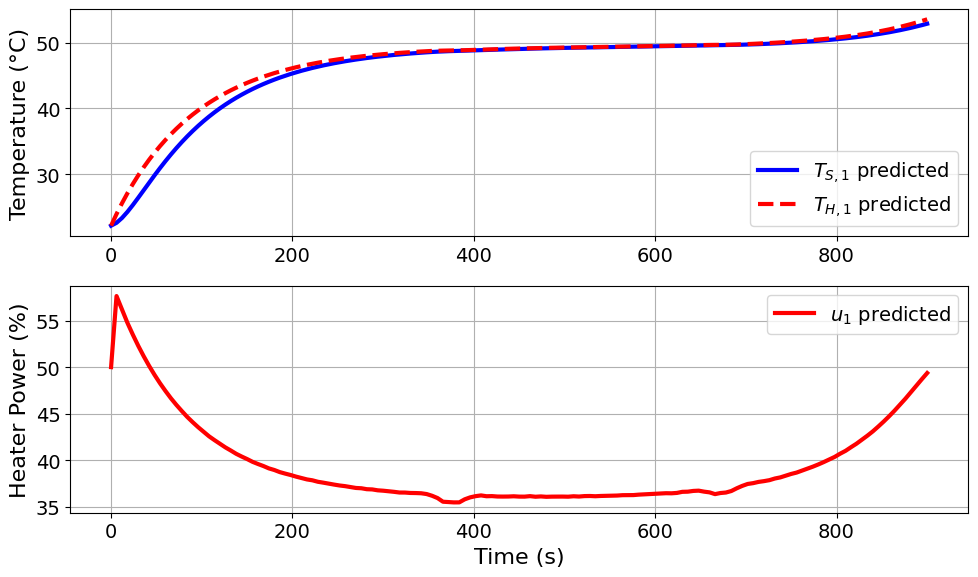

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.22 Joules/°C
 


In [11]:
Aopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_pA.model.fd_scenario_blocks[0])

Interesting! The pseudo-A-optimal design pushes the heater power and then the heater power gradually decreases before rising again. 

In [12]:
FIM_pA = np.asarray(TC_Lab_DoE_pA.results['FIM'])
if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_unscaled = D @ FIM_pA @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_unscaled = FIM_pA / SCALE_CONSTANT_VALUE**2
results_summary(np.asarray(FIM_unscaled))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.910302962865462
A-optimality: -4.855996627248806
D-optimality: 31.037359540804864
E-optimality: 4.857406506172812
Modified E-optimality: 4.999072134273759

FIM:
 [[ 7.17766519e+09  1.00811750e+08 -2.18903352e+08 -8.93427504e+04]
 [ 1.00811750e+08  8.99331580e+08  1.51888655e+08  2.51214462e+06]
 [-2.18903352e+08  1.51888655e+08  5.69015067e+07  4.84151439e+05]
 [-8.93427504e+04  2.51214462e+06  4.84151439e+05  7.91462314e+04]]

eigenvalues:
 [7.18585816e+09 9.25285883e+08 2.27613731e+07 7.20122708e+04]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9994   -0.0098   -0.0326   -0.0000
Ub        -0.0153    0.9846    0.1743   -0.0024
inv_CpH    0.0304    0.1747   -0.9842   -0.0020
inv_CpS    0.0000    0.0028   -0.0016    1.0000


## Activity: Change the initial point
Careful initialization is important for most complex optimization problems. In this exericse, we will change the initial design point and observe if that changes the result we got just now.

In the last experiment, we used the sine data for initialization. We will change that in our exercise.

In [13]:
skip = 6

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

We now modify the initial heater-power profile $u_1$ and check whether the optimizer converges to the same design or a different local solution.

In [14]:
from dataclasses import replace
# =========================== ACTIVITY ===============================
# ------------------- Choose a new design for u1 -------------------
# Set a random seed for reproducibility
SEED: int = 105 # Choose any integer seed you like
PDF = "uniform" # Choose between "normal" or "uniform" distribution for the new design of u1
# ------------------------------------------------------------------

rng = np.random.default_rng(seed=SEED)

if PDF == "normal":
    u1_design = rng.normal(loc=50.0, scale=10.0, size=len(tc_data.time))
    # Normal distribution is unbounded, so we need to clip the values to be within the 
    # bounds of the control input, which is [0, 100] in this case.
    u1_design = np.clip(u1_design, 0.0, 100.0)    
elif PDF == "uniform":
    u1_design = rng.uniform(low=0.0, high=100.0, size=len(tc_data.time))


# Create a new data object with only u1 replaced
tc_data_2 = replace(tc_data, u1=u1_design)

# Build the experiment with the new design variable
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)

### Optimize experiment with new initial point
Create the `DesignOfExperiments` object and optimize the next experiment with our newly initialized dataclass.

In [ ]:
from pyomo.contrib.doe import DesignOfExperiments

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_pA_2 = DesignOfExperiments(
    experiment=doe_experiment_2,
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="pseudo_trace",
    prior_FIM=PRIOR_FIM_SCALED,
    solver=solver,
    tee=True,
    jac_initial=init_jac,
    fim_initial=init_fim,
)

TC_Lab_DoE_pA_2.run_doe()

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

#### Analyze the new result

Let's start with plotting the data from our new result.

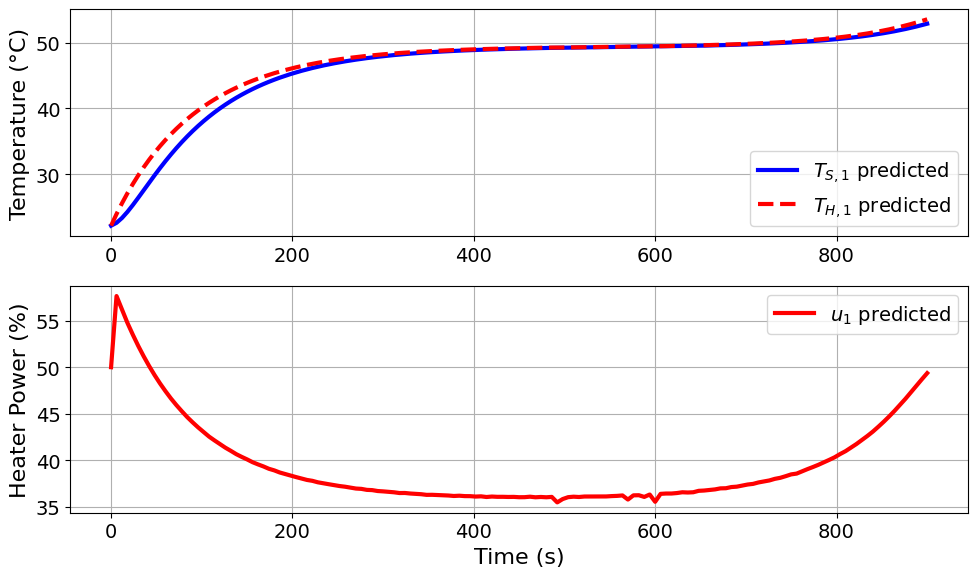

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.22 Joules/°C
 


In [16]:
Aopt_pyomo_doe_results_2 = extract_plot_results(None, TC_Lab_DoE_pA_2.model.fd_scenario_blocks[0])

Compare the resulting design and information metrics with the previous solution.

In [17]:
FIM_pA_2 = np.asarray(TC_Lab_DoE_pA_2.results['FIM'])
if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_unscaled_2 = D @ FIM_pA_2 @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_unscaled_2 = FIM_pA_2 / SCALE_CONSTANT_VALUE**2
results_summary(np.asarray(FIM_unscaled_2))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.910302962501355
A-optimality: -4.855939678379907
D-optimality: 31.03730242297983
E-optimality: 4.857349372087751
Modified E-optimality: 4.999129268465867

FIM:
 [[ 7.17766520e+09  1.00811750e+08 -2.18903353e+08 -8.93457302e+04]
 [ 1.00811750e+08  8.99331580e+08  1.51888655e+08  2.51214458e+06]
 [-2.18903353e+08  1.51888655e+08  5.69015076e+07  4.84154394e+05]
 [-8.93457302e+04  2.51214458e+06  4.84154394e+05  7.91367700e+04]]

eigenvalues:
 [7.18585816e+09 9.25285883e+08 2.27613740e+07 7.20027978e+04]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9994   -0.0098   -0.0326   -0.0000
Ub        -0.0153    0.9846    0.1743   -0.0024
inv_CpH    0.0304    0.1747   -0.9842   -0.0020
inv_CpS    0.0000    0.0028   -0.0016    1.0000


**Discussion**: How does the new result compare to our previous analysis? It is possible to get a different result here since the problem is non-convex. Therefore, multiple optima may exist for our problem. 